<a href="https://colab.research.google.com/github/IrisCheon/NLP-practice/blob/main/Stack_Overflow_Question_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stack Overflow Question and Answer Analysis

This project explores Python-related Stack Overflow questions and answers using simple pandas-based text analysis.

The analysis focuses on:
- score distributions
- text length
- differences between questions and answers
- observations from actual post contents

The dataset contains separate question and answer files with limited metadata such as:
- title
- body
- score

The goal of this project is not to build a prediction model, but to observe basic patterns in technical discussion texts.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("stackoverflow/pythonquestions")

print("Path to dataset files:", path)

100%|██████████| 558M/558M [00:05<00:00, 107MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/stackoverflow/pythonquestions/versions/2


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [3]:
os.listdir(path)

['Tags.csv', 'Answers.csv', 'Questions.csv']

In [6]:
df_questions = pd.read_csv(os.path.join(path, "Questions.csv"), encoding='latin1')
df_answers = pd.read_csv(os.path.join(path, "Answers.csv"), encoding='latin1')

# ■ 데이터 확인

In [7]:
df_questions.head()

,Id,OwnerUserId,CreationDate,Score,Title,Body
0,469,147.0,2008-08-02T15:11:16Z,21,How can I find the full path to a font from it...,<p>I am using the Photoshop's javascript API t...
1,502,147.0,2008-08-02T17:01:58Z,27,Get a preview JPEG of a PDF on Windows?,<p>I have a cross-platform (Python) applicatio...
2,535,154.0,2008-08-02T18:43:54Z,40,Continuous Integration System for a Python Cod...,<p>I'm starting work on a hobby project with a...
3,594,116.0,2008-08-03T01:15:08Z,25,cx_Oracle: How do I iterate over a result set?,<p>There are several ways to iterate over a re...
4,683,199.0,2008-08-03T13:19:16Z,28,Using 'in' to match an attribute of Python obj...,<p>I don't remember whether I was dreaming or ...


In [8]:
df_answers.head()

,Id,OwnerUserId,CreationDate,ParentId,Score,Body
0,497,50.0,2008-08-02T16:56:53Z,469,4,<p>open up a terminal (Applications-&gt;Utilit...
1,518,153.0,2008-08-02T17:42:28Z,469,2,<p>I haven't been able to find anything that d...
2,536,161.0,2008-08-02T18:49:07Z,502,9,<p>You can use ImageMagick's convert utility f...
3,538,156.0,2008-08-02T18:56:56Z,535,23,<p>One possibility is Hudson. It's written in...
4,541,157.0,2008-08-02T19:06:40Z,535,20,"<p>We run <a href=""http://buildbot.net/trac"">B..."


In [10]:
df_questions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607282 entries, 0 to 607281
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Id            607282 non-null  int64  
 1   OwnerUserId   601070 non-null  float64
 2   CreationDate  607282 non-null  object 
 3   Score         607282 non-null  int64  
 4   Title         607282 non-null  object 
 5   Body          607282 non-null  object 
dtypes: float64(1), int64(2), object(3)
memory usage: 27.8+ MB


In [11]:
df_questions = df_questions[["Score", "Title", "Body"]]
df_questions.head()

,Score,Title,Body
0,21,How can I find the full path to a font from it...,<p>I am using the Photoshop's javascript API t...
1,27,Get a preview JPEG of a PDF on Windows?,<p>I have a cross-platform (Python) applicatio...
2,40,Continuous Integration System for a Python Cod...,<p>I'm starting work on a hobby project with a...
3,25,cx_Oracle: How do I iterate over a result set?,<p>There are several ways to iterate over a re...
4,28,Using 'in' to match an attribute of Python obj...,<p>I don't remember whether I was dreaming or ...


In [34]:
df_questions = df_questions.sample(n=10000, random_state=42)

In [44]:
df_answers = df_answers[["Score", "Body"]]
df_answers = df_answers.sample(n=10000, random_state = 42)

df_answers.head()

,Score,Body
361010,0,<p>First:</p>\n\n<p><code>__main__</code> indi...
21592,7,"<p>In this case, you need to make your functio..."
556166,2,<pre><code>import pandas as pd\ndf = pd.read_t...
564528,6,<p>Trying to stream information from one proce...
894025,1,<p>Ah I am editing as I didn't know you had a ...


# ■ Score

In [36]:
df_questions["Score"].value_counts()

,count
Score,
0,3942
1,2422
2,1196
3,588
-1,333
...,...
180,1
150,1
610,1


In [52]:
df_questions["Score"].describe()

,Score
count,10000.000000
mean,2.222300
std,12.353718
min,-9.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,610.000000


※ min은 -9점, max 610점. 75%까지도 2점. 극히 대부분이 0~2점에 분포

<Axes: xlabel='Score'>

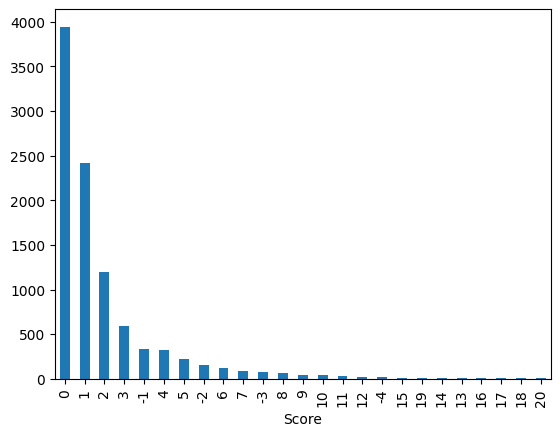

In [69]:
score_counts_questions = df_questions["Score"].value_counts()
frequent_scores_questions = score_counts_questions[score_counts_questions >= 10].index
frequent_score_questions_df = df_questions[df_questions["Score"].isin(frequent_scores_questions)]

frequent_score_questions_df["Score"].value_counts().plot(kind="bar")

※ 대부분의 questions 점수는 0점. 0~3점이 대부분임
- 음수 score를 기록한 questions가 4점을 기록한 questions와 비슷
- 20 이상 score를 받은 질문은 10개 미만

In [45]:
df_answers["Score"].value_counts()

,count
Score,
0,3241
1,2633
2,1456
3,813
4,469
...,...
182,1
147,1
122,1


In [53]:
df_answers["Score"].describe()

,Score
count,10000.000000
mean,3.295500
std,34.783591
min,-7.000000
25%,0.000000
50%,1.000000
75%,3.000000
max,2443.000000


※ min -7, max 2443. 50%까지의 평균이 1이지만 75%가 3점으로 questions보다는 높음

<Axes: xlabel='Score'>

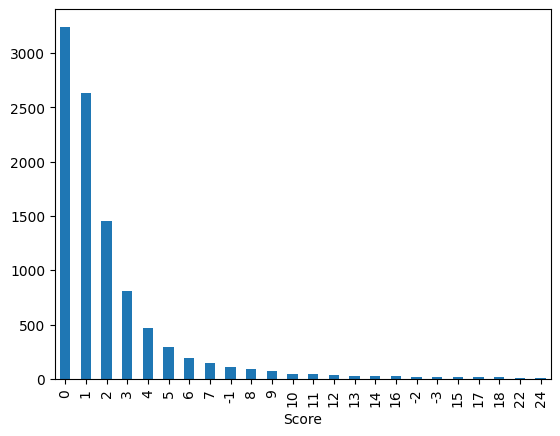

In [76]:
score_counts_answers = df_answers["Score"].value_counts()
frequent_scores_answers = score_counts_answers[score_counts_answers >= 10].index
frequent_scores_answers_df = df_answers[df_answers["Score"].isin(frequent_scores_answers)]

frequent_scores_answers_df["Score"].value_counts().plot(kind="bar")

※ questions보다 전반적인 score가 확연히 높아 보임
- 음수 score는 드문 편
- 20 이상의 score를 기록한 answer도 10개 이상

# ■ Text_length

In [54]:
df_questions["text_length"] = df_questions["Body"].str.len()
df_questions.head()

,Score,Title,Body,text_length
429244,-2,Calculating the Letter Frequency in Python,<p>I need to define a function that will slice...,1892
95946,5,Minimum Methods for Ordering with Duck Typing ...,"<p>In <a href=""http://docs.python.org/release/...",1354
78980,1,omniORBpy terminating the server,<p>I'm working on python client-server applica...,719
498301,1,Pulling value from sqlite3 DB in Python,<p>I'm writing a script that inserts win/loss ...,727
414200,-3,Prime number(Python 3),"<p>My goal is to build a programm, that says i...",1164


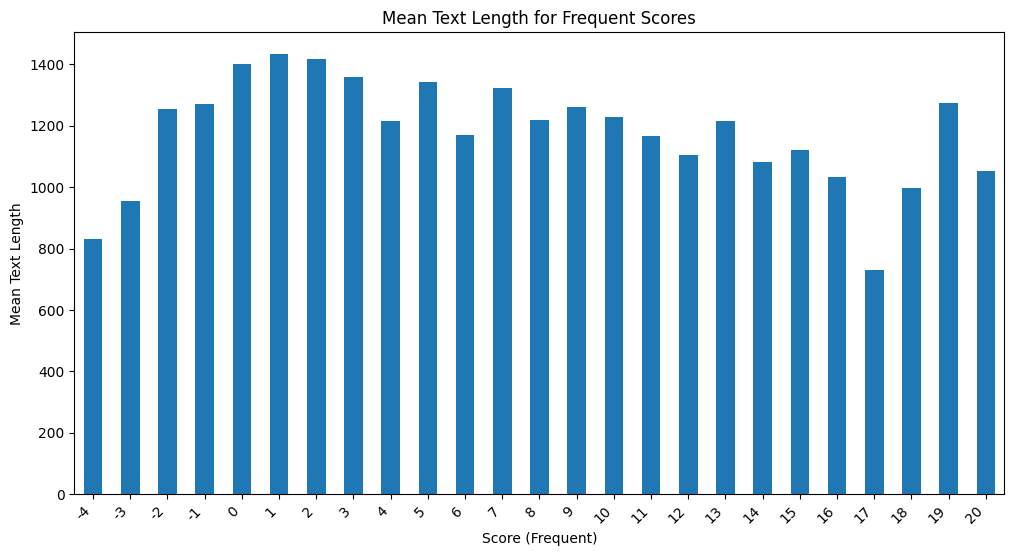

In [73]:
mean_text_length_by_frequent_score = frequent_score_questions_df.groupby("Score")["text_length"].mean()

mean_text_length_by_frequent_score.plot(kind="bar", figsize=(12, 6))
plt.xlabel("Score (Frequent)")
plt.ylabel("Mean Text Length")
plt.title("Mean Text Length for Frequent Scores")
plt.xticks(rotation=45, ha='right') # X축 레이블이 겹치지 않도록 회전
plt.show()

※ questions에서 score와 text length는 크게 상관관계가 없음

In [55]:
df_answers["text_length"] = df_answers["Body"].str.len()
df_answers.head()

,Score,Body,text_length
361010,0,<p>First:</p>\n\n<p><code>__main__</code> indi...,1716
21592,7,"<p>In this case, you need to make your functio...",1188
556166,2,<pre><code>import pandas as pd\ndf = pd.read_t...,1242
564528,6,<p>Trying to stream information from one proce...,2952
894025,1,<p>Ah I am editing as I didn't know you had a ...,319


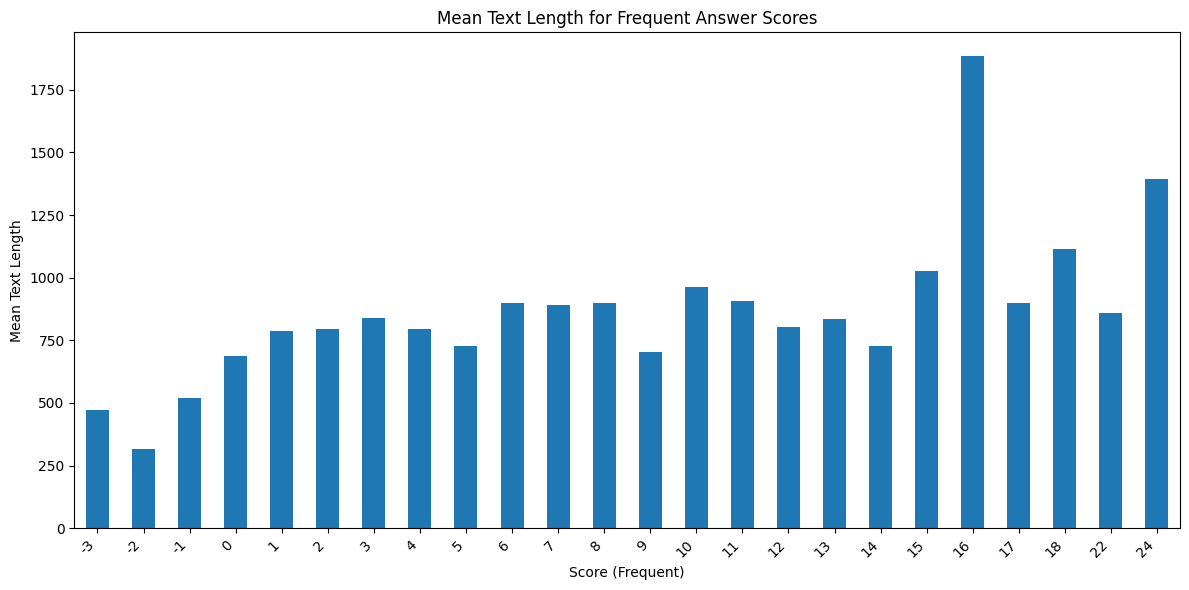

In [79]:
mean_text_length_by_frequent_score_answer = frequent_scores_answers_df.groupby("Score")["text_length"].mean()

mean_text_length_by_frequent_score_answer.plot(kind="bar", figsize=(12, 6))
plt.xlabel("Score (Frequent)")
plt.ylabel("Mean Text Length")
plt.title("Mean Text Length for Frequent Answer Scores")
plt.xticks(rotation=45, ha='right') # X축 레이블이 겹치지 않도록 회전
plt.tight_layout() # 레이아웃 조정
plt.show()

※ answer은 정확하지 않지만, 하위 3개의 score의 text length에 비해 상위 3개의 length가 확연히 길다

# ■ 실제 내용 확인

In [94]:
# 최악의 questions 확인

for i in range(5):
    print(i, "="*30)
    print("▶Score: ",
        df_questions.sort_values("Score", ascending=True)["Score"].iloc[i]
          )
    print(
        df_questions.sort_values("Score", ascending=True)["Body"].iloc[i]
    )
    i += 1

0 ==============================
▶Score:  -9
<p>I am using Python 3.4.3. The <code>math.floor</code> function is giving me different answers for positive and negative numbers. For example:</p>

<pre><code>&gt;&gt;&gt; math.floor (19.8)
19

&gt;&gt;&gt; math.floor (-19.8)
-20
</code></pre>

<p>Why am I getting this difference in the answer?</p>

1 ==============================
▶Score:  -7
<p>Hi guys i'm Learning python, i have this problem, for not create 1000 "if" function i would did that:</p>

<pre><code>#Vari flag
print "choose flag"
print "(1) Syn"
print "(2) Ack"
print "(3) Push"
print "(4) Fin"
print "(5) Urg"
print "(6) Rst"

flag-list = ["--syn","--ack","--push","--fin","--urg","--rst"]
flag = raw_input(write number separated by comma: )
</code></pre>

<p>now i would take writed number and transform them in the text of "flag-list".</p>

2 ==============================
▶Score:  -7
<p>How do I split a string at the second underscore in Python so that I get something like this</

※ 조금 더 세부적인 / 단순히 코드를 던져놓았다 같은 느낌의 내용인 것 같음

In [93]:
# 최상의 questions 확인

for i in range(5):
    print(i, "="*30)
    print("▶Score: ",
        df_questions.sort_values("Score", ascending=False)["Score"].iloc[i]
          )
    print(
        df_questions.sort_values("Score", ascending=False)["Body"].iloc[i]
    )
    i += 1

0 ==============================
▶Score:  610
<p>How do I remove leading and trailing whitespace from a string in Python?</p>

<p>For example:</p>

<pre><code>" Hello " --&gt; "Hello"
" Hello"  --&gt; "Hello"
"Hello "  --&gt; "Hello"
"Bob has a cat" --&gt; "Bob has a cat"
</code></pre>

1 ==============================
▶Score:  586
<p>What is the purpose of the <code>self</code> word in Python? I understand it refers to the specific object created from that class, but I can't see why it explicitly needs to be added to every function as a parameter. To illustrate, in Ruby I can do this:</p>

<pre><code>class myClass
    def myFunc(name)
        @name = name
    end
end
</code></pre>

<p>Which I understand, quite easily. However in Python I need to include <code>self</code>:</p>

<pre><code>class myClass:
    def myFunc(self, name):
        self.name = name
</code></pre>

<p>Can anyone talk me through this? It is not something I've come across in my (admittedly limited) experience.</p>



※ 상대적으로 일반적인 내용 질문으로 보임
- 비슷한 궁금증이 있는 사람들로부터 score를 받은 것으로 추정

In [95]:
# 최악의 answers 확인

for i in range(5):
    print(i, "="*30)
    print("▶Score: ",
        df_answers.sort_values("Score", ascending=True)["Score"].iloc[i]
          )
    print(
        df_answers.sort_values("Score", ascending=True)["Body"].iloc[i]
    )
    i += 1

0 ==============================
▶Score:  -7
<p>Try this:</p>

<pre><code>&gt;&gt;&gt; import hashlib
&gt;&gt;&gt; m = hashlib.md5()
&gt;&gt;&gt; m.update("000005fab4534d05api_key9a0554259914a86fb9e7eb014e4e5d52permswrite")
&gt;&gt;&gt; print m.hexdigest()
a02506b31c1cd46c2e0b6380fb94eb3d
</code></pre>

<p>First line <code>python</code> is to initialize python on a mac.</p>

1 ==============================
▶Score:  -6
<p>You could do something like the following:</p>

<pre><code>globals()['foo'] = 10
</code></pre>

<p>or</p>

<pre><code>locals()['foo'] = 10
</code></pre>

<p>And then you can access foo by its name after that. From your other question, it seems like your asking how do you make an array (in Python, it's usually a list) without using square brackets.</p>

<p>Unlike C/C++, you do not need to declare the type of a Python variable, so you can do something like:</p>

<pre><code>foo = []
</code></pre>

<p>or</p>

<pre><code>foo = list()
</code></pre>

<p>Where the variable na

※ 마찬가지로 코드만 던져놓았다 라는 느낌.
- 이외로, 위 답변으로 해결되지 않았기에 score가 음수이지 않을까 추정

In [96]:
# 최고의 answers 확인

for i in range(5):
    print(i, "="*30)
    print("▶Score: ",
        df_answers.sort_values("Score", ascending=False)["Score"].iloc[i]
          )
    print(
        df_answers.sort_values("Score", ascending=False)["Body"].iloc[i]
    )
    i += 1

0 ==============================
▶Score:  2443
<p>When the Python interpreter reads a source file, it executes all of the code found in it.  </p>

<p>Before executing the code, it will define a few special variables.  For example, if the python interpreter is running that module (the source file) as the main program, it sets the special <code>__name__</code> variable to have a value <code>"__main__"</code>.  If this file is being imported from another module, <code>__name__</code> will be set to the module's name.</p>

<p>In the case of your script, let's assume that it's executing as the main function, e.g. you said something like</p>

<pre><code>python threading_example.py
</code></pre>

<p>on the command line.  After setting up the special variables, it will execute the <code>import</code> statement and load those modules.  It will then evaluate the <code>def</code> block, creating a function object and creating a variable called <code>myfunction</code> that points to the function o

※ 전반적으로 길고, 설명이 많아 보임. low scores와 다르게 단순히 코드를 던져놓은 것으로는 보이지 않음

# ■ Conclusion

Most questions and answers had very low scores, while only a small number of posts received high scores.

Question length did not show a clear relationship with score. However, higher-scoring answers were generally longer and contained more explanations compared to lower-scoring answers.

By reading actual examples, low-scoring posts were often short code-only responses, while higher-scoring posts usually included explanations together with code examples.

This project was useful for practicing pandas-based text analysis and exploring basic patterns in Stack Overflow posts.